### <font color='blue'> Machine Learning - Adult Income Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# csv files
# df_standardized.to_csv('Adult_income_standardized.csv')
# df_normalized.to_csv('Adult_income_normalized.csv')

## <font color='blue'> Build the Model

### Split the data into test and train

In [2]:
from sklearn.model_selection import train_test_split

norm_df = pd.read_csv('Adult_income_normalized.csv')
# Remove target column 'income' so that the remaining columns will be the features
X = norm_df.drop('income', axis=1)  
y = norm_df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
X.columns

Index(['age', 'education-num', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_local-gov', 'workclass_never-worked',
       'workclass_private', 'workclass_self-emp-inc',
       'workclass_self-emp-not-inc', 'workclass_state-gov',
       'workclass_without-pay', 'marital-status_married-af-spouse',
       'marital-status_married-civ-spouse',
       'marital-status_married-spouse-absent', 'marital-status_never-married',
       'marital-status_separated', 'marital-status_widowed',
       'occupation_craft-repair', 'occupation_exec-managerial',
       'occupation_farming-fishing', 'occupation_handlers-cleaners',
       'occupation_machine-op-inspct', 'occupation_other-service',
       'occupation_prof-specialty', 'occupation_sales',
       'occupation_transport-moving', 'relationship_not-in-family',
       'relationship_other-relative', 'relationship_own-child',
       'relationship_unmarried', 'relationship_wife',
       'race_asian-pac-islander', 'race_black', 

In [4]:
y

0        False
1        False
2        False
3        False
4        False
         ...  
48319    False
48320    False
48321    False
48322    False
48323     True
Name: income, Length: 48324, dtype: bool

### <font color='blue'> Logistic Regression </font>
#### Logistic regression is a supervised machine learning algorithm used for classification tasks where the goal is to predict the probability that an instance belongs to a given class or not. Logistic regression is a statistical algorithm which analyze the relationship between two data factors.

******** Classification report ******** 
               precision    recall  f1-score   support

       False       0.88      0.93      0.90      7412
        True       0.71      0.58      0.64      2253

    accuracy                           0.85      9665
   macro avg       0.79      0.76      0.77      9665
weighted avg       0.84      0.85      0.84      9665

******** Confusion Matrix ********


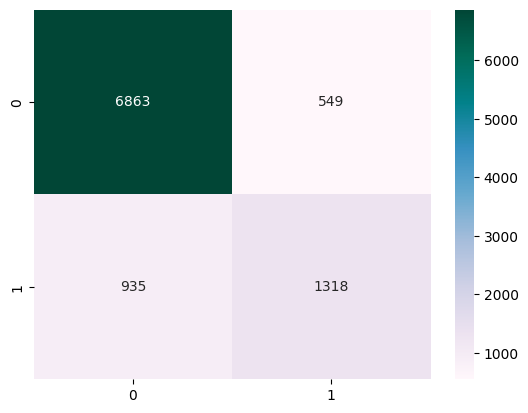

******** Accuracy Score ******** 0.846456285566477


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# train logistic regression model
model_LR = LogisticRegression(max_iter=1000)
model_LR.fit(X_train, y_train)

# evaluate the model
y_pred = model_LR.predict(X_test)

LogisticRegression_Acc = accuracy_score(y_test, y_pred)
print('******** Classification report ******** \n',classification_report(y_test, y_pred))
print('******** Confusion Matrix ********')

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',cmap='PuBuGn')
plt.show()

print("******** Accuracy Score ********",LogisticRegression_Acc)

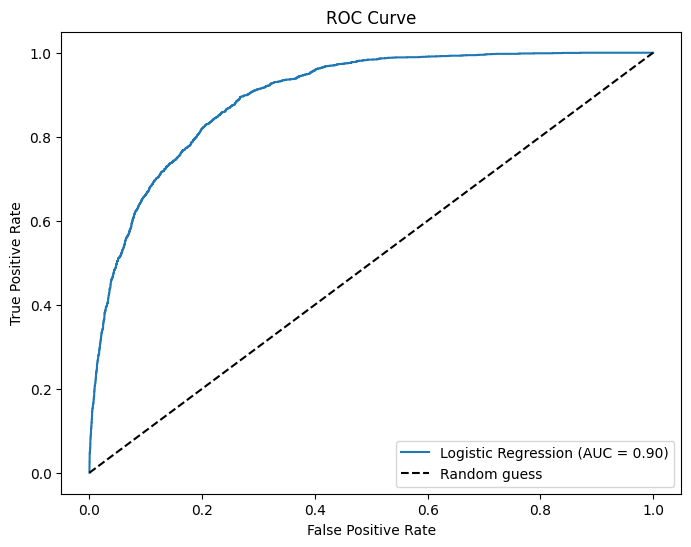

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities
y_scores_LR = model_LR.predict_proba(X_test)[:, 1]  # probability for class 1

# Calculate ROC curve and AUC score
fpr_LR, tpr_LR, thresholds = roc_curve(y_test, y_scores_LR)
auc_score_LR = roc_auc_score(y_test, y_scores_LR)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_LR, tpr_LR, label=f"Logistic Regression (AUC = {auc_score_LR:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
#plt.grid(True)
plt.show()

### <font color='blue'> Random Forest Classifier

******** Classification report ******** 
               precision    recall  f1-score   support

       False       0.88      0.91      0.90      7412
        True       0.68      0.61      0.64      2253

    accuracy                           0.84      9665
   macro avg       0.78      0.76      0.77      9665
weighted avg       0.84      0.84      0.84      9665

******** Confusion Matrix ********


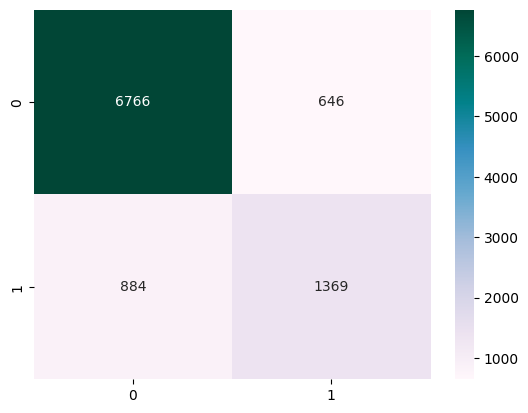

******** Accuracy Score ******** 0.8416968442834971


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# train a random forest model
model_RF = RandomForestClassifier(n_estimators=100, random_state=42)
model_RF.fit(X_train, y_train)

# evaluate the model
y_pred = model_RF.predict(X_test)

RandomForest_Acc = accuracy_score(y_test, y_pred)
print('******** Classification report ******** \n',classification_report(y_test, y_pred))
print('******** Confusion Matrix ********')

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',cmap='PuBuGn')
plt.show()

print("******** Accuracy Score ********", RandomForest_Acc)

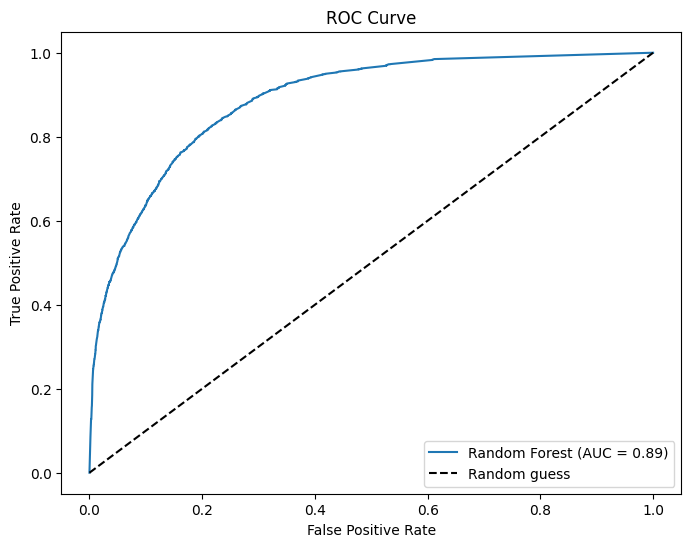

In [32]:
# Predict probabilities
y_scores_RF = model_RF.predict_proba(X_test)[:, 1]  # probability for class 1

# Calculate ROC curve and AUC score
fpr_RF, tpr_RF, thresholds = roc_curve(y_test, y_scores_RF)
auc_score_RF = roc_auc_score(y_test, y_scores_RF)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_RF, tpr_RF, label=f"Random Forest (AUC = {auc_score_RF:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

### <font color='blue'> XG Boosting

******** CLASSIFICATION_REPORT ******** 
               precision    recall  f1-score   support

       False       0.90      0.94      0.92      7412
        True       0.77      0.65      0.70      2253

    accuracy                           0.87      9665
   macro avg       0.83      0.80      0.81      9665
weighted avg       0.87      0.87      0.87      9665

******** CONFUSION MATRIX ********


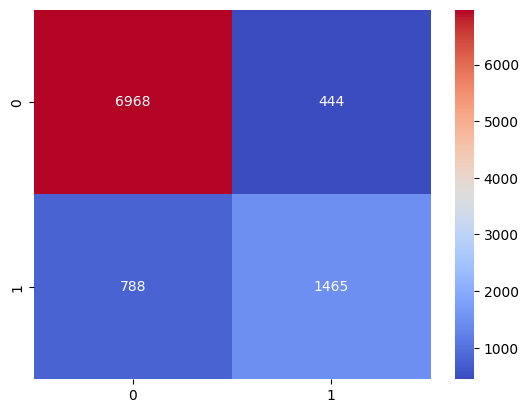

******** ACCURACY_SCORE ******** 0.8725297465080186


In [7]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

model_XGB = XGBClassifier()
model_XGB.fit(X_train, y_train)

# evaluate the model
y_pred = model_XGB.predict(X_test)

XGBoost_Acc = accuracy_score(y_test, y_pred)
print('******** CLASSIFICATION_REPORT ******** \n', classification_report(y_test, y_pred))
print('******** CONFUSION MATRIX ********')
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',cmap='coolwarm')
plt.show()
print('******** ACCURACY_SCORE ********', XGBoost_Acc)

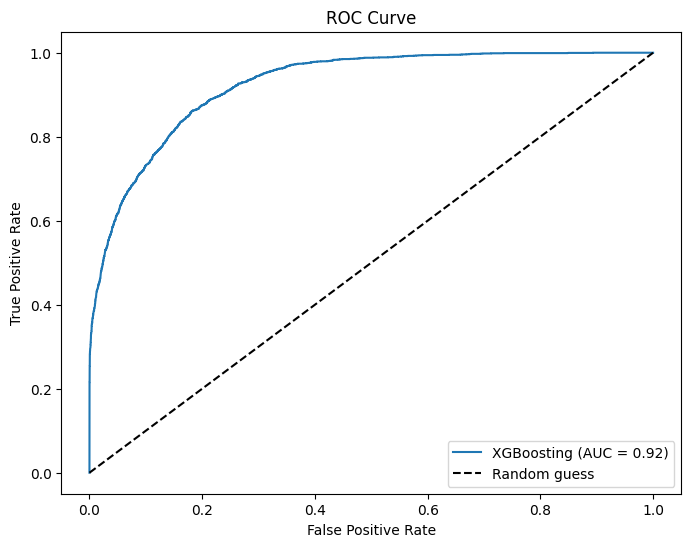

In [35]:
# Predict probabilities
y_scores_XGB = model_XGB.predict_proba(X_test)[:, 1]  # probability for class 1

# Calculate ROC curve and AUC score
fpr_XGB, tpr_XGB, thresholds = roc_curve(y_test, y_scores_XGB)
auc_score_XGB = roc_auc_score(y_test, y_scores_XGB)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_XGB, tpr_XGB, label=f"XGBoosting (AUC = {auc_score_XGB:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [8]:
model_XGB.feature_names_in_

array(['age', 'education-num', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_local-gov', 'workclass_never-worked',
       'workclass_private', 'workclass_self-emp-inc',
       'workclass_self-emp-not-inc', 'workclass_state-gov',
       'workclass_without-pay', 'marital-status_married-af-spouse',
       'marital-status_married-civ-spouse',
       'marital-status_married-spouse-absent',
       'marital-status_never-married', 'marital-status_separated',
       'marital-status_widowed', 'occupation_craft-repair',
       'occupation_exec-managerial', 'occupation_farming-fishing',
       'occupation_handlers-cleaners', 'occupation_machine-op-inspct',
       'occupation_other-service', 'occupation_prof-specialty',
       'occupation_sales', 'occupation_transport-moving',
       'relationship_not-in-family', 'relationship_other-relative',
       'relationship_own-child', 'relationship_unmarried',
       'relationship_wife', 'race_asian-pac-islander', 'race_black',


### <font color='blue'>SVM

******** CLASSIFICATION_REPORT ******** 
               precision    recall  f1-score   support

       False       0.88      0.93      0.90      7412
        True       0.72      0.58      0.64      2253

    accuracy                           0.85      9665
   macro avg       0.80      0.75      0.77      9665
weighted avg       0.84      0.85      0.84      9665

******** CONFUSION MATRIX ********


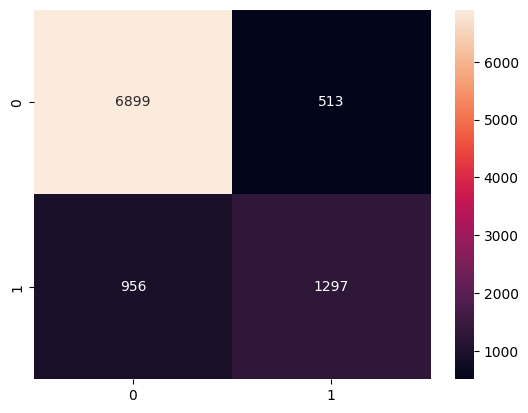

******** ACCURACY_SCORE ******** 0.8480082772891878


In [9]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVC

# Create and fit the SVM classifier
model_SVM = SVC()
model_SVM.fit(X_train, y_train)

# evaluate the model
y_pred = model_SVM.predict(X_test)

SVM_Acc = accuracy_score(y_test, y_pred)
print('******** CLASSIFICATION_REPORT ******** \n', classification_report(y_test, y_pred))
print('******** CONFUSION MATRIX ********')
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()
print('******** ACCURACY_SCORE ********', SVM_Acc)

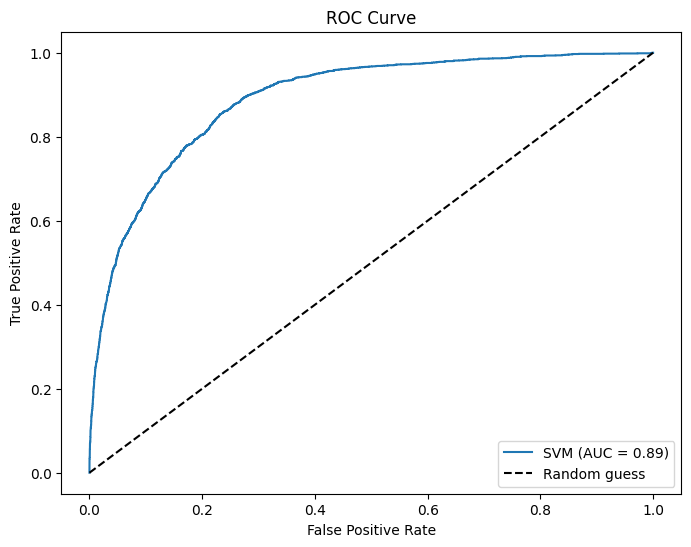

In [37]:
# Predict probabilities
y_scores_SVM = model_SVM.decision_function(X_test)  

# Calculate ROC curve and AUC score
fpr_SVM, tpr_SVM, thresholds = roc_curve(y_test, y_scores_SVM)
auc_score_SVM = roc_auc_score(y_test, y_scores_SVM)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_SVM, tpr_SVM, label=f"SVM (AUC = {auc_score_SVM:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

### <font color='blue'>KNN

******** CLASSIFICATION_REPORT ******** 
               precision    recall  f1-score   support

       False       0.88      0.90      0.89      7412
        True       0.64      0.58      0.61      2253

    accuracy                           0.83      9665
   macro avg       0.76      0.74      0.75      9665
weighted avg       0.82      0.83      0.82      9665

******** CONFUSION MATRIX ********


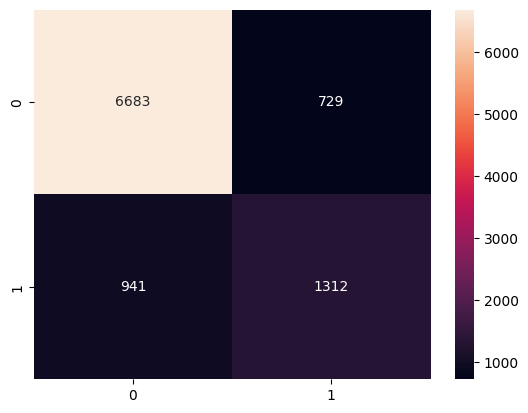

******** ACCURACY_SCORE ******** 0.827211588204863


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create and fit the KNN classifier
model_KNN =  KNeighborsClassifier(n_neighbors=5)
model_KNN.fit(X_train, y_train)

# evaluate the model
y_pred = model_KNN.predict(X_test)

KNN_Acc = accuracy_score(y_test, y_pred)
print('******** CLASSIFICATION_REPORT ******** \n', classification_report(y_test, y_pred))
print('******** CONFUSION MATRIX ********')
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()
print('******** ACCURACY_SCORE ********', KNN_Acc)


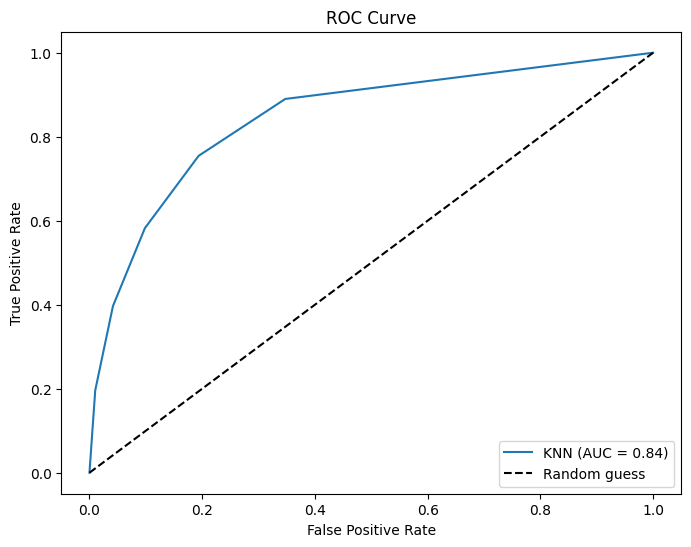

In [38]:
# Predict probabilities
y_scores_KNN = model_KNN.predict_proba(X_test)[:, 1]  # probability for class 1

# Calculate ROC curve and AUC score
fpr_KNN, tpr_KNN, thresholds = roc_curve(y_test, y_scores_KNN)
auc_score_KNN = roc_auc_score(y_test, y_scores_KNN)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_KNN, tpr_KNN, label=f"KNN (AUC = {auc_score_KNN:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

## <font color='blue'> Hyper Parameter Tunning </font>
###### Hyperparameter tuning is the process of selecting the optimal values for a machine learning model's hyperparameters. Hyperparameters are configuration settings that control the learning process of the model.

Models can have many hyperparameters and finding the best combination of parameters can be treated as a search problem. 

| Technique                                | Pros                                                 | Cons                           | Best Use                                            |
| ---------------------------------------- | ---------------------------------------------------- | ------------------------------ | --------------------------------------------------- |
| **GridSearchCV**                         | Exhaustive, guaranteed best (within grid)            | Expensive, slow on large grids | Small datasets, or few hyperparams                  |
| **RandomizedSearchCV**                   | Fast, scalable, good coverage                        | Might miss exact best combo    | Large feature space, tight compute budget           |
| **Bayesian Optimization (e.g., Optuna)** | Smarter search, better results with fewer iterations | More complex setup             | When performance is critical and compute is limited |
| **Manual tuning**                        | Simple                                               | Time-consuming, not scalable   | For experienced practitioners or quick prototyping  |

##### Lets use GridSearchCV method for tuning our model.
GridSearchCV is often considered a “brute force” approach to hyperparameter optimization. It works by fitting the model using all possible combinations of predefined hyperparameter values. A grid of potential discrete values for each hyperparameter is created and the model is trained for each possible combination. The performance of each set is logged and the combination that produces the best results is selected.

### <font color='blue'> Tuned Random Forest </font>
##### This is a hyperparameter tuning utility from sklearn.model_selection that
        Tries all combinations of parameters you define
        Evaluates them using cross-validation
        Selects the best model based on the chosen scoring metric
<ul>
    <li> <b>estimator=rf</b>  the model you want to tune </li>
    <li> <b>param_grid_rf</b>  dictionary of hyperparameters and values you want to search over.</li>
    <ul><li> Number of trees (n_estimators)
        <li> Tree depth (max_depth)
        <li> Minimum samples to split a node (min_samples_split)
        <li> Minimum samples in a leaf (min_samples_leaf)
        <li> This creates a grid of combinations. If each parameter has 2 values → 2×3×2×2×2 = 48 combinations. Each will be evaluated using 5-fold cross-validation. </ul>
    <li> <b>cv=5</b>  means 5-fold cross-validation:</li>
    <ul><li> The training data is split into 5 parts.
        <li> For each parameter combination, the model is trained on 4 parts and validated on the 5th.
        <li> This process repeats 5 times, and the average accuracy is computed.
        <li> This ensures the results are robust and not overfitted.
    </ul>
    <li> <b>scoring='accuracy'</b>  Tells GridSearchCV to select best model based on accuracy — the proportion of correct predictions</li>
    <li> <b>n_jobs=-1</b>  Use all available CPU cores to train models in parallel. Greatly reduces the time needed to search large grids </li>
</ul>

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf,
                       cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

tuned_RF = grid_rf.best_estimator_

print("Best RF Params:", grid_rf.best_params_)
print("Best CV Accuracy:", grid_rf.best_score_)

Best RF Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Accuracy: 0.8635763107430978


In [11]:
y_pred = grid_rf.predict(X_test)
Tuned_RF_Acc = accuracy_score(y_test, y_pred)
print('******** CLASSIFICATION_REPORT ******** \n', classification_report(y_test, y_pred))
print('******** ACCURACY_SCORE ********', Tuned_RF_Acc)

******** CLASSIFICATION_REPORT ******** 
               precision    recall  f1-score   support

       False       0.89      0.94      0.91      7412
        True       0.76      0.62      0.68      2253

    accuracy                           0.86      9665
   macro avg       0.82      0.78      0.80      9665
weighted avg       0.86      0.86      0.86      9665

******** ACCURACY_SCORE ******** 0.8647697878944646


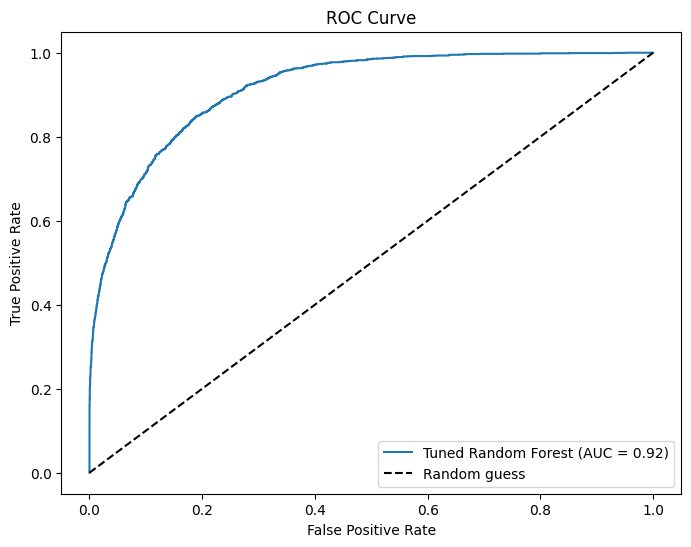

In [43]:
# Predict probabilities
y_scores_RF = grid_rf.predict_proba(X_test)[:, 1]  # probability for class 1

# Calculate ROC curve and AUC score
fpr_RF_tuned, tpr_RF_tuned, thresholds = roc_curve(y_test, y_scores_RF)
auc_score_RF_tuned = roc_auc_score(y_test, y_scores_RF)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_RF_tuned, tpr_RF_tuned, label=f"Tuned Random Forest (AUC = {auc_score_RF_tuned:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

### <font color='blue'> Tuned Logistic Regression </font>
##### This is a brute-force search over a grid of hyperparameter values using cross-validation to find the best combination.
<ul>
    <li> <b>estimator=logreg</b>  the model you want to tune </li>
    <li> <b>param_grid_lr</b>  dictionary of hyperparameters and values you want to search over.</li>
    <ol>
        <li> GridSearchCV will test all combinations of:</li>
            penalty: 'l1' and 'l2'
            C: 0.01, 0.1, 1, 10, 100
        <li> Total combinations: 2 penalties × 5 C values = 10 models</li>
    </ol>
    <li> <b>cv=5</b>  means 5-fold cross-validation:</li>
    <ol> 
        <li> The training data is split into 5 parts.
        <li> For each parameter combination, the model is trained on 4 parts and validated on the 5th.
        <li> This process repeats 5 times, and the average accuracy is computed.
        <li> Cross-validation helps reduce overfitting and gives a more reliable estimate of model performance.
    </ol>
    <li> <b>scoring='accuracy'</b>  Tells GridSearchCV to evaluate models using accuracy (i.e., correct predictions / total predictions). Other scoring options could be 'f1', 'roc_auc', etc. </li>
    <li> <b>n_jobs=-1</b>  enables parallel computation -> -1 uses all available CPU cores to speed up training. Especially useful when tuning large grids. </li>
</ul>

In [12]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(solver='liblinear', random_state=42)

param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(estimator=logreg, param_grid=param_grid_lr,
                       cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train, y_train)

tuned_LR = grid_lr.best_estimator_

print("Best Logistic Params:", grid_lr.best_params_)
print("Best CV Accuracy:", grid_lr.best_score_)


Best Logistic Params: {'C': 100, 'penalty': 'l2'}
Best CV Accuracy: 0.8435809186053849


In [14]:
y_pred = grid_lr.predict(X_test)
Tuned_LR_Acc = accuracy_score(y_test, y_pred)
print('******** CLASSIFICATION_REPORT ******** \n', classification_report(y_test, y_pred))
print('******** ACCURACY_SCORE ********', Tuned_LR_Acc)

******** CLASSIFICATION_REPORT ******** 
               precision    recall  f1-score   support

       False       0.88      0.93      0.90      7412
        True       0.71      0.58      0.64      2253

    accuracy                           0.85      9665
   macro avg       0.79      0.76      0.77      9665
weighted avg       0.84      0.85      0.84      9665

******** ACCURACY_SCORE ******** 0.8468701500258665


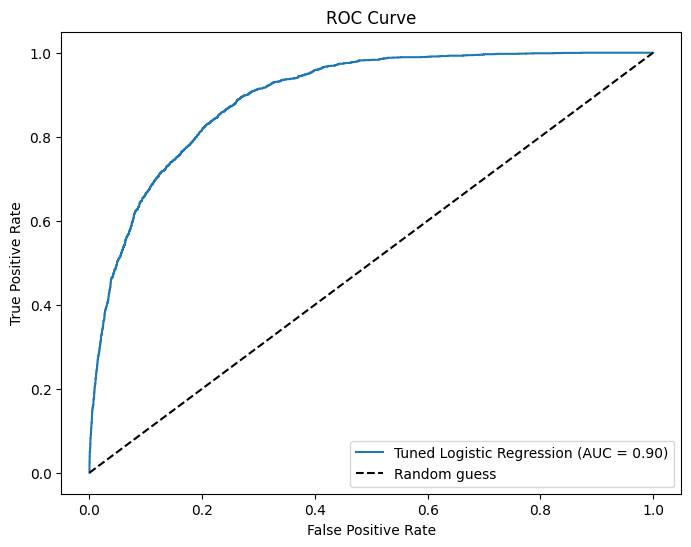

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities
y_scores_LR = grid_lr.predict_proba(X_test)[:, 1]  # probability for class 1

# Calculate ROC curve and AUC score
fpr_LR_tuned, tpr_LR_tuned, thresholds = roc_curve(y_test, y_scores_LR)
auc_score_LR_tuned = roc_auc_score(y_test, y_scores_LR)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_LR_tuned, tpr_LR_tuned, label=f"Tuned Logistic Regression (AUC = {auc_score_LR_tuned:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
#plt.grid(True)
plt.show()

### <font color='blue'> Tuned XGBoosting </font>

| Parameter                   | Meaning                                                                                                                               |
| --------------------------- | -----------------------------------------------------------------------------------------------
| `estimator=xgb`             | This is the model you want to tune — in this case, it's an XGBoost classifier                 |
| `param_grid=param_grid_xgb` | A dictionary of hyperparameters and the values to try.            |
| `cv=5`                      | Use 5-fold cross-validation. The dataset is split into 5 parts — training on 4 and validating on 1, cycling through all combinations. |
| `scoring='accuracy'`        | Metric used to evaluate performance during tuning. In this case, it’s accuracy.                                                       |
| `n_jobs=-1`                 | Uses all available CPU cores to speed up the search.                                                                                  |


In [15]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
}

grid_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid_xgb,
                        cv=5, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

tuned_XGB = grid_xgb.best_estimator_

print("Best XGB Params:", grid_xgb.best_params_)
print("Best CV Accuracy:", grid_xgb.best_score_)


C:\Users\ganes\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:23:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB Params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Best CV Accuracy: 0.8704052851096389


In [24]:
y_pred = grid_xgb.predict(X_test)
Tuned_XGBoost = accuracy_score(y_test, y_pred)
print('******** CLASSIFICATION_REPORT ******** \n', classification_report(y_test, y_pred))
print('******** ACCURACY_SCORE ********', Tuned_XGBoost)

******** CLASSIFICATION_REPORT ******** 
               precision    recall  f1-score   support

       False       0.90      0.94      0.92      7412
        True       0.78      0.64      0.70      2253

    accuracy                           0.87      9665
   macro avg       0.84      0.79      0.81      9665
weighted avg       0.87      0.87      0.87      9665

******** ACCURACY_SCORE ******** 0.874495602690119


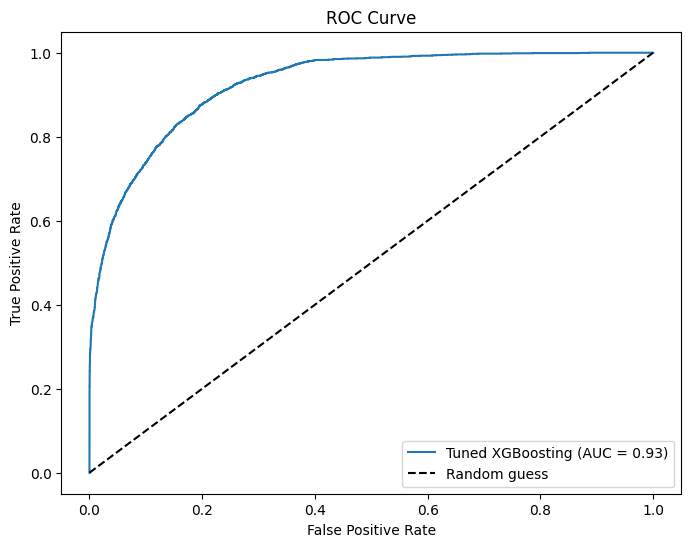

In [42]:
# Predict probabilities
y_scores_XGB = grid_xgb.predict_proba(X_test)[:, 1]  # probability for class 1

# Calculate ROC curve and AUC score
fpr_XGB_tuned, tpr_XGB_tuned, thresholds = roc_curve(y_test, y_scores_XGB)
auc_score_XGB_tuned = roc_auc_score(y_test, y_scores_XGB)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_XGB_tuned, tpr_XGB_tuned, label=f"Tuned XGBoosting (AUC = {auc_score_XGB_tuned:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

### <font color='blue'> Tuned SVM </font>

In [17]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_svm.fit(X_train, y_train)

tuned_SVM = grid_svm.best_estimator_

print("Best parameters:", grid_svm.best_params_)
print("Best CV accuracy:", grid_svm.best_score_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy: 0.8449777713805713


In [18]:
y_pred = grid_svm.predict(X_test)
Tuned_SVM_Acc = accuracy_score(y_test, y_pred)
print('******** CLASSIFICATION_REPORT ******** \n', classification_report(y_test, y_pred))
print('******** ACCURACY_SCORE ********', Tuned_SVM_Acc)

******** CLASSIFICATION_REPORT ******** 
               precision    recall  f1-score   support

       False       0.88      0.93      0.91      7412
        True       0.72      0.59      0.65      2253

    accuracy                           0.85      9665
   macro avg       0.80      0.76      0.78      9665
weighted avg       0.84      0.85      0.85      9665

******** ACCURACY_SCORE ******** 0.8508018623900673


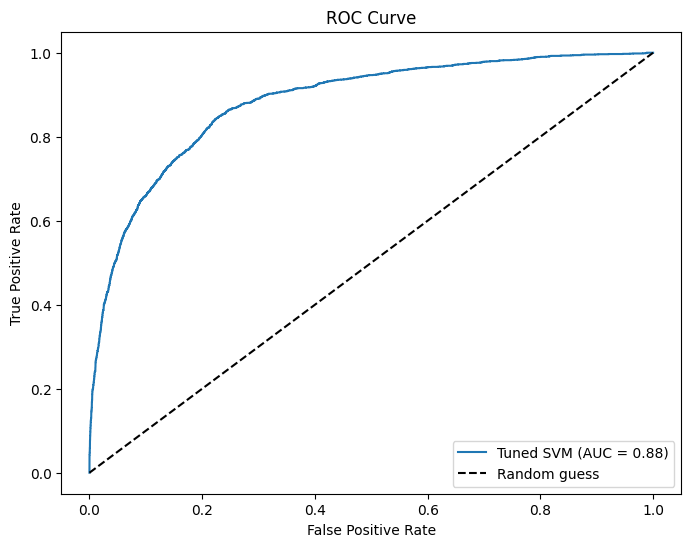

In [40]:
# Predict probabilities
y_scores_SVM = grid_svm.decision_function(X_test)  

# Calculate ROC curve and AUC score
fpr_SVM_tuned, tpr_SVM_tuned, thresholds = roc_curve(y_test, y_scores_SVM)
auc_score_SVM_tuned = roc_auc_score(y_test, y_scores_SVM)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_SVM_tuned, tpr_SVM_tuned, label=f"Tuned SVM (AUC = {auc_score_SVM_tuned:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

### <font color='blue'> Tuned KNN </font>

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid
param_grid = {
    'n_neighbors': list(range(1, 21)),        # try 1 to 20 neighbors
    'weights': ['uniform', 'distance'],       # uniform: equal weight, distance: closer = more weight
    'metric': ['euclidean', 'manhattan']      # distance metrics
}

# Initialize base KNN model
knn = KNeighborsClassifier()

# Grid Search with 5-fold CV
grid_knn = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train, y_train)

tuned_KNN = grid_knn.best_estimator_

print("Best Parameters:", grid_knn.best_params_)
print("Best CV Accuracy:", grid_knn.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 20, 'weights': 'uniform'}
Best CV Accuracy: 0.8368295304417023


In [25]:
y_pred = grid_knn.predict(X_test)
Tuned_KNN_Acc = accuracy_score(y_test, y_pred)
print('******** CLASSIFICATION_REPORT ******** \n', classification_report(y_test, y_pred))
print('******** ACCURACY_SCORE ********', Tuned_KNN_Acc)

******** CLASSIFICATION_REPORT ******** 
               precision    recall  f1-score   support

       False       0.87      0.93      0.90      7412
        True       0.70      0.55      0.62      2253

    accuracy                           0.84      9665
   macro avg       0.79      0.74      0.76      9665
weighted avg       0.83      0.84      0.83      9665

******** ACCURACY_SCORE ******** 0.8406621831350233


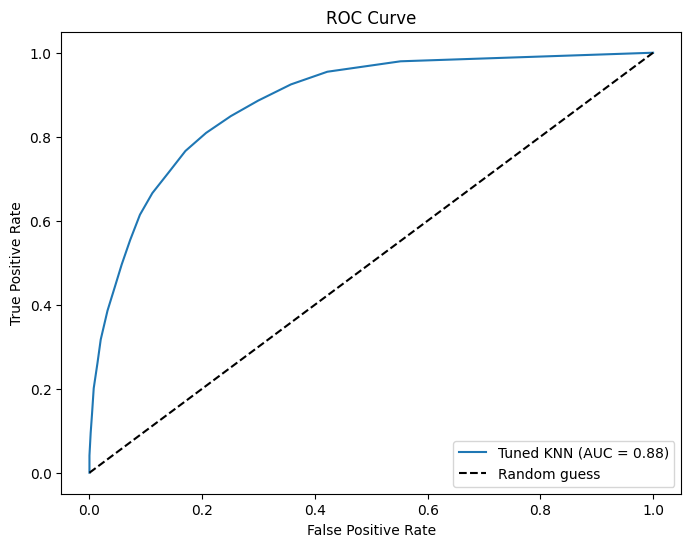

In [41]:
# Predict probabilities
y_scores_KNN = grid_knn.predict_proba(X_test)[:, 1]  # probability for class 1

# Calculate ROC curve and AUC score
fpr_KNN_tuned, tpr_KNN_tuned, thresholds = roc_curve(y_test, y_scores_KNN)
auc_score_KNN_tuned = roc_auc_score(y_test, y_scores_KNN)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_KNN_tuned, tpr_KNN_tuned, label=f"Tuned KNN (AUC = {auc_score_KNN_tuned:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

#### Accuracy score from the binary classification algorithms and tuned hyper parameters

In [47]:
results=pd.DataFrame(
    {
        'Algorithms' : ['LogisticRegression','RandomForest','XGBoosting','SVM','KNN','TunedRandomForest',
                        'TunedLogisticRegression','TunedXGBoosting','TunedSVM','TunedKNN'],
        'Accuracy' : [LogisticRegression_Acc,RandomForest_Acc,XGBoost_Acc,SVM_Acc,KNN_Acc,Tuned_RF_Acc,
                      Tuned_LR_Acc,Tuned_XGBoost, Tuned_SVM_Acc,Tuned_KNN_Acc],
        'False_Ratio' : [fpr_LR,fpr_RF,fpr_XGB,fpr_SVM,fpr_KNN,
                         fpr_RF_tuned,fpr_LR_tuned,fpr_XGB_tuned,fpr_SVM_tuned,fpr_KNN_tuned],
        'True_Ratio' : [tpr_LR,tpr_RF,tpr_XGB,tpr_SVM,tpr_KNN,
                        tpr_RF_tuned,tpr_LR_tuned,tpr_XGB_tuned,tpr_SVM_tuned,tpr_KNN_tuned],
        'AUC_Score' : [auc_score_LR,auc_score_RF,auc_score_XGB,auc_score_SVM,auc_score_KNN,
                       auc_score_RF_tuned,auc_score_LR_tuned, auc_score_XGB_tuned, auc_score_SVM_tuned, auc_score_KNN_tuned]
    }
)
results.to_csv('Results_Normalized.csv')
results

,Algorithms,Accuracy,False_Ratio,True_Ratio,AUC_Score
0,LogisticRegression,0.846456,"[0.0, 0.0, 0.0, 0.00013491635186184566, 0.0001...","[0.0, 0.0004438526409232135, 0.011540168664003...",0.896262
1,RandomForest,0.841697,"[0.0, 0.0014840798704803021, 0.001618996222342...","[0.0, 0.07856191744340879, 0.07856191744340879...",0.888264
2,XGBoosting,0.872530,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0004438526409232135, 0.009320905459387...",0.924196
3,SVM,0.848008,"[0.0, 0.0, 0.0, 0.00013491635186184566, 0.0001...","[0.0, 0.0004438526409232135, 0.027075011096316...",0.889946
4,KNN,0.827212,"[0.0, 0.01025364274150027, 0.04168915272531030...","[0.0, 0.19618286728806036, 0.3968042609853529,...",0.844854
5,TunedRandomForest,0.864770,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0004438526409232135, 0.001775410563692...",0.915989
6,TunedLogisticRegression,0.846870,"[0.0, 0.0, 0.0, 0.00013491635186184566, 0.0001...","[0.0, 0.0004438526409232135, 0.011540168664003...",0.896265
7,TunedXGBoosting,0.874496,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0004438526409232135, 0.002663115845539...",0.925792
8,TunedSVM,0.850802,"[0.0, 0.0, 0.0, 0.00013491635186184566, 0.0001...","[0.0, 0.0004438526409232135, 0.035952063914780...",0.882341
9,TunedKNN,0.840662,"[0.0, 0.0, 0.0021586616297895305, 0.0045871559...","[0.0, 0.040834442964935644, 0.0949844651575676...",0.883365


### <font color='green'> Conclusion </font>
#### <font color='green'> Based on the models accuracy, we conclude that 'Tuned XGBoosting' is the best prediction model for our adult income dataset.

In [22]:
import joblib
joblib.dump(model_LR, "n_model_LR.pkl")
joblib.dump(model_RF, "n_model_RF.pkl")
joblib.dump(model_SVM, "n_model_SVM.pkl")
joblib.dump(model_XGB, "n_model_XGB.pkl")
joblib.dump(model_KNN, "n_model_KNN.pkl")

['n_model_KNN.pkl']

In [23]:
joblib.dump(tuned_LR, "n_tuned_LR.pkl")
joblib.dump(tuned_RF, "n_tuned_RF.pkl")
joblib.dump(tuned_SVM, "n_tuned_SVM.pkl")
joblib.dump(tuned_XGB, "n_tuned_XGB.pkl")
joblib.dump(tuned_KNN, "n_tuned_KNN.pkl")

['n_tuned_KNN.pkl']